In [2]:
# ================================
# STEP 1: Import Library
# ================================
import pandas as pd
# ================================
# STEP 2: Load Dataset
# ================================
df = pd.read_csv("fraud_ecommerce_1M.csv")
# first 5 rows dekhne ke liye
df.head()

,order_id,customer_id,product,category,price,quantity,discount_percent,payment_mode,city,rating,discounted_price,total_amount,order_date,fraud_flag
0,1,80204,Laptop,Home,45035,3,3,COD,Lucknow,2.7,43683.95,131051.85,2023-01-01 00:00:00,0
1,2,46705,Mobile,Sports,86611,1,26,COD,Mumbai,4.2,64092.14,64092.14,2023-01-01 00:01:00,0
2,3,23299,Shoes,Sports,9317,3,2,NetBanking,Noida,1.5,9130.66,27391.98,2023-01-01 00:02:00,0
3,4,43281,TV,Fashion,53949,4,2,Card,Delhi,3.6,52870.02,211480.08,2023-01-01 00:03:00,0
4,5,17501,Watch,Sports,92439,1,42,NetBanking,Pune,2.3,53614.62,53614.62,2023-01-01 00:04:00,0


In [4]:
# ================================
# STEP 3: Basic Information
# ================================
# total rows and columns
print("Shape:", df.shape)

# data types aur null values check
df.info()

# statistical summary (mean, min, max etc.)
df.describe()



Shape: (1000000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   order_id          1000000 non-null  int64  
 1   customer_id       1000000 non-null  int64  
 2   product           1000000 non-null  object 
 3   category          1000000 non-null  object 
 4   price             1000000 non-null  int64  
 5   quantity          1000000 non-null  int64  
 6   discount_percent  1000000 non-null  int64  
 7   payment_mode      1000000 non-null  object 
 8   city              1000000 non-null  object 
 9   rating            1000000 non-null  float64
 10  discounted_price  1000000 non-null  float64
 11  total_amount      1000000 non-null  float64
 12  order_date        1000000 non-null  object 
 13  fraud_flag        1000000 non-null  int64  
dtypes: float64(3), int64(6), object(5)
memory usage: 106.8+ MB


,order_id,customer_id,price,quantity,discount_percent,rating,discounted_price,total_amount,fraud_flag
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,54996.353592,50213.937548,2.499421,34.460355,3.002564,32911.864163,82277.797133,0.273197
std,288675.278932,25984.435561,28718.679410,1.117624,20.209998,1.156273,22157.832157,70964.545703,0.445601
min,1.000000,10000.000000,500.000000,1.000000,0.000000,1.000000,156.240000,156.240000,0.000000
25%,250000.750000,32498.000000,25324.000000,1.000000,17.000000,2.000000,14880.240000,28573.637500,0.000000
50%,500000.500000,54979.000000,50203.000000,2.000000,34.000000,3.000000,29479.450000,61529.600000,0.000000
75%,750000.250000,77487.000000,75078.250000,3.000000,52.000000,4.000000,47495.157500,117509.760000,1.000000
max,1000000.000000,99998.000000,99999.000000,4.000000,69.000000,5.000000,99996.000000,399948.000000,1.000000


In [5]:
# ================================
# STEP 4: Fraud vs Normal Count
# ================================
# 0 = normal, 1 = fraud
fraud_counts = df["fraud_flag"].value_counts()
print("\nFraud vs Normal Transactions:")
print(fraud_counts)


Fraud vs Normal Transactions:
fraud_flag
0    726803
1    273197
Name: count, dtype: int64


In [6]:
# ================================
# STEP 5: Category-wise Fraud
# ================================
# kaunsi category me kitna fraud hua
category_fraud = df.groupby("category")["fraud_flag"].sum()
print("\nCategory Wise Fraud:")
print(category_fraud)


Category Wise Fraud:
category
Electronics    68209
Fashion        68220
Home           68518
Sports         68250
Name: fraud_flag, dtype: int64


In [7]:
# ================================
# STEP 6: Payment Mode Fraud
# ================================
# kaunsa payment mode risky hai
payment_fraud = df.groupby("payment_mode")["fraud_flag"].sum()
print("\nPayment Mode Fraud:")
print(payment_fraud)


Payment Mode Fraud:
payment_mode
COD           68357
Card          68295
NetBanking    67839
UPI           68706
Name: fraud_flag, dtype: int64


In [8]:
# ================================
# STEP 7: City-wise Fraud
# ================================
# kaunse city me fraud zyada hai
city_fraud = df.groupby("city")["fraud_flag"].sum()
print("\nCity Wise Fraud:")
print(city_fraud)


City Wise Fraud:
city
Delhi      45608
Kanpur     45430
Lucknow    46149
Mumbai     45248
Noida      45370
Pune       45392
Name: fraud_flag, dtype: int64


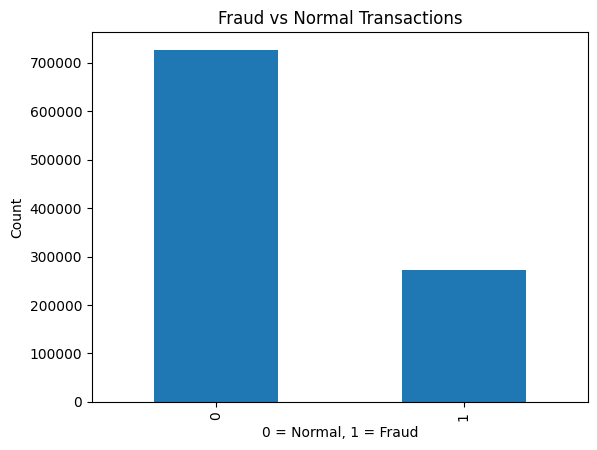

In [10]:
# ================================
# STEP 8: Visualization
# ================================
import matplotlib.pyplot as plt
# Fraud vs Normal graph
df["fraud_flag"].value_counts().plot(kind="bar")
plt.title("Fraud vs Normal Transactions")
plt.xlabel("0 = Normal, 1 = Fraud")
plt.ylabel("Count")
plt.show()

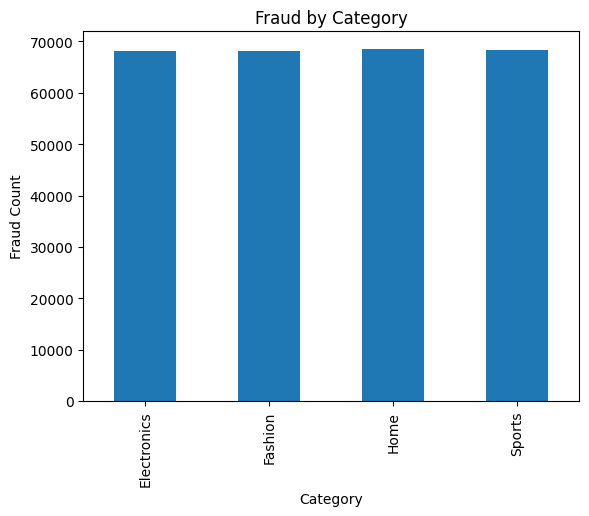

In [11]:
# Category wise fraud graph
category_fraud.plot(kind="bar")
plt.title("Fraud by Category")
plt.xlabel("Category")
plt.ylabel("Fraud Count")
plt.show()

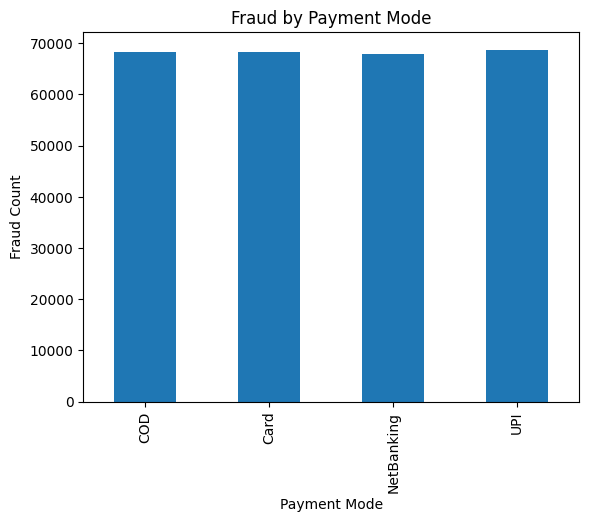

In [12]:
# Payment mode fraud graph
payment_fraud.plot(kind="bar")
plt.title("Fraud by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Fraud Count")
plt.show()

In [13]:
# ================================
# STEP 9: Advanced Analysis
# ================================
# average transaction amount by payment mode
avg_amount = df.groupby("payment_mode")["total_amount"].mean()
print("\nAverage Transaction Amount by Payment Mode:")
print(avg_amount)


Average Transaction Amount by Payment Mode:
payment_mode
COD           82174.411623
Card          82333.389727
NetBanking    82124.228975
UPI           82478.304625
Name: total_amount, dtype: float64


In [14]:
# high value fraud transactions (top 10)
high_fraud = df[df["fraud_flag"] == 1].sort_values(by="total_amount", ascending=False).head(10)
print("\nTop 10 High Value Fraud Transactions:")
print(high_fraud)


Top 10 High Value Fraud Transactions:
        order_id  customer_id     product     category  price  quantity  \
440484    440485        70837  Headphones      Fashion  99987         4   
515440    515441        38978         Bag         Home  99951         4   
419644    419645        18175          TV  Electronics  99926         4   
380703    380704        81591         Bag         Home  99891         4   
372755    372756        57903  Headphones         Home  99859         4   
22036      22037        51804      Laptop       Sports  99856         4   
913843    913844        23943       Watch         Home  99853         4   
454274    454275        50105       Watch       Sports  99832         4   
629479    629480        62655      Mobile       Sports  99825         4   
912385    912386        92932          TV         Home  99792         4   

        discount_percent payment_mode     city  rating  discounted_price  \
440484                 0   NetBanking  Lucknow     3.6     